# Food to Recipe Generation using CLIP + Microsoft Phi-2

## Project Overview

This notebook implements a deep learning system that generates cooking recipes from images of food using **CLIP** for food recognition and **Microsoft Phi-2** for recipe generation.

### Key Features:
- ✅ **Vision Understanding**: CLIP for accurate food recognition
- ✅ **Efficient Language Model**: Microsoft Phi-2 for recipe generation
- ✅ **Better Generation Quality**: More coherent and accurate recipes
- ✅ **Instruction Following**: Phi-2 is instruction-tuned for better prompts

### Approach
1. **CLIP**: Food recognition (100+ categories)
2. **Microsoft Phi-2**: Efficient language model for recipe generation
3. **Training**: Fine-tune Phi-2 on food-recipe pairs
4. **Evaluation**: Monitor quality and coherence

### Model References:
- [Microsoft Phi-2](https://huggingface.co/microsoft/phi-2)


In [1]:
# import sys
# import subprocess

# packages = [
#     "torch",
#     "torchvision", 
#     "transformers>=4.37.0",
#     "pillow",
#     "pandas",
#     "matplotlib",
#     "seaborn",
#     "accelerate",
#     "bitsandbytes",
#     "gradio>=5.0.0"
# ]

# print("Installing required packages...")
# for package in packages:
#     print(f"Installing {package}...")
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# print("\n✓ All packages installed successfully!")


## Installation Requirements

```bash
pip install torch torchvision
pip install transformers>=4.37.0
pip install pillow pandas matplotlib seaborn
pip install accelerate bitsandbytes
pip install gradio
```


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import zipfile
import os
import re
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Hugging Face Libraries
from transformers import (
    CLIPProcessor, CLIPModel,
    AutoModelForCausalLM,  # Use AutoModelForCausalLM for Phi-2
    AutoProcessor,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer
)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Set device - MULTI-GPU SUPPORT
# First, clear any existing CUDA state to avoid conflicts
if torch.cuda.is_available():
    try:
        torch.cuda.empty_cache()
        # Synchronize to catch any existing errors
        for i in range(torch.cuda.device_count()):
            try:
                torch.cuda.synchronize(i)
            except:
                pass
    except:
        pass

if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Found {num_gpus} GPU(s)")
    
    if num_gpus > 1:
        device = torch.device("cuda")
        use_multi_gpu = True
        print(f"Using MULTI-GPU training with {num_gpus} GPUs")
        for i in range(num_gpus):
            gpu_name = torch.cuda.get_device_name(i)
            print(f"  GPU {i}: {gpu_name}")
    else:
        device = torch.device("cuda")
        use_multi_gpu = False
        print(f"Using single GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    use_multi_gpu = False
    print("Using CPU (No GPU available)")

print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")

print("\n✓ Libraries imported successfully!")
print("\n⚠️ If you encounter CUDA errors, try:")
print("   1. Restart the kernel")
print("   2. Run this cell again to reset CUDA state")
print("   3. If errors persist, restart Jupyter and clear GPU memory")


Found 2 GPU(s)
Using MULTI-GPU training with 2 GPUs
  GPU 0: NVIDIA GeForce RTX 3090
  GPU 1: NVIDIA GeForce RTX 3090

PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA version: 12.8

✓ Libraries imported successfully!

⚠️ If you encounter CUDA errors, try:
   1. Restart the kernel
   2. Run this cell again to reset CUDA state
   3. If errors persist, restart Jupyter and clear GPU memory


## 1. Dataset Loading

Using the same dataset as the Janus version for consistency.


In [3]:
# Extract dataset (reusing from original notebook)
zip_files = [
    "Food Ingredients and Recipe Dataset with Image Name Mapping.csv.zip"
]

for zip_file in zip_files:
    if os.path.exists(zip_file):
        print(f"Extracting {zip_file}...")
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(".")
        print(f"✓ Extracted successfully!")

target_csv = "Food Ingredients and Recipe Dataset with Image Name Mapping.csv"
if os.path.exists(target_csv):
    print(f"\n✓ Found dataset: {target_csv}")
    main_dataset = pd.read_csv(target_csv)
    print(f"✓ Loaded {len(main_dataset)} recipes")
else:
    print(f"\n✗ Dataset '{target_csv}' not found!")



✓ Found dataset: Food Ingredients and Recipe Dataset with Image Name Mapping.csv
✓ Loaded 13501 recipes


## 2. Load CLIP for Food Recognition


In [4]:
# Load CLIP for food recognition (same as before)
print("Loading CLIP model (ViT-B/32)...")

# Reset CUDA state before loading CLIP to avoid conflicts
if torch.cuda.is_available():
    try:
        # Clear any existing CUDA errors
        torch.cuda.empty_cache()
        # Synchronize all CUDA operations
        for i in range(torch.cuda.device_count()):
            try:
                torch.cuda.synchronize(i)
            except:
                pass
        # Reset error state
        torch.cuda.reset_peak_memory_stats()
        print("✓ CUDA state cleared")
    except Exception as e:
        print(f"⚠️ Warning clearing CUDA state: {e}")

try:
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    
    # Freeze CLIP weights
    for param in clip_model.parameters():
        param.requires_grad = False
    
    # Move to device - use cuda:0 explicitly to avoid multi-GPU conflicts
    if torch.cuda.is_available():
        clip_device = torch.device("cuda:0")  # Use first GPU explicitly
        print(f"Moving CLIP model to {clip_device}")
        clip_model = clip_model.to(clip_device)
    else:
        clip_model = clip_model.to(device)
    
    clip_model.eval()
    
    print("✓ CLIP model loaded and frozen!")
    
except RuntimeError as e:
    if "CUDA" in str(e) or "cuda" in str(e).lower():
        print(f"⚠️ CUDA error encountered: {e}")
        print("Attempting to reset CUDA and reload CLIP on CPU...")
        try:
            # Reset CUDA
            torch.cuda.empty_cache()
            # Fallback to CPU
            clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
            clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
            for param in clip_model.parameters():
                param.requires_grad = False
            clip_model = clip_model.to("cpu")
            clip_model.eval()
            print("✓ CLIP model loaded on CPU as fallback")
        except Exception as e2:
            print(f"❌ Failed to load CLIP: {e2}")
            raise
    else:
        raise


Loading CLIP model (ViT-B/32)...
✓ CUDA state cleared


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Moving CLIP model to cuda:0
✓ CLIP model loaded and frozen!


## 3. Load Microsoft Phi-2

This notebook uses Microsoft Phi-2, an efficient instruction-tuned language model for recipe generation.

**Note**: Phi-2 is available on Hugging Face and works well for text generation tasks.


In [ ]:
# Load Microsoft Phi-2 - OPTIMIZED FOR MULTI-GPU
print("Loading Microsoft Phi-2...")
print("This may take a few minutes...")

# Model configuration
model_name = "microsoft/phi-2"  # Microsoft Phi-2 language model

try:
    # Load Phi-2 model
    minimax_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if use_multi_gpu else None,
        low_cpu_mem_usage=True,
        trust_remote_code=True,
    )
    
    # Move to device if not using device_map
    if not use_multi_gpu:
        minimax_model = minimax_model.to(device)
    
    # Load tokenizer
    minimax_tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    
    # Phi-2 uses tokenizer only (no separate processor)
    minimax_processor = minimax_tokenizer
    
    print("✓ Microsoft Phi-2 loaded successfully!")
    print(f"Model parameters: {sum(p.numel() for p in minimax_model.parameters()):,}")
    
    if use_multi_gpu:
        print(f"✓ Model distributed across {num_gpus} GPUs for parallel training")
        
except Exception as e:
    print(f"❌ Error loading Phi-2: {e}")
    raise


Loading MiniMax-M1...
This may take a few minutes...
Note: Model identifier may need adjustment based on official release
⚠️ Error loading MiniMax-M1: MiniMax-AI/MiniMax-M1 is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
This might be because:
  1. Model is not yet available on Hugging Face
  2. Model identifier needs to be updated
  3. Custom installation from GitHub is required

Please check https://github.com/MiniMax-AI/MiniMax-M1 for correct installation instructions
For now, using a placeholder that demonstrates the structure

Using fallback model: microsoft/phi-2


`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.86it/s]


⚠️ Using fallback model - structure is correct for MiniMax-M1 when available


## 4. Prepare Dataset

Process the dataset for training with Microsoft Phi-2.


In [ ]:
# Find image files
def find_image_file(image_name, search_dirs=['food_images/Food Images', 'food_images', '.']):
    extensions = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']
    
    for directory in search_dirs:
        if not os.path.exists(directory):
            continue
        
        for ext in extensions:
            path = os.path.join(directory, image_name + ext)
            if os.path.exists(path) and os.path.isfile(path):
                return path
    
    return None

# Process dataset for Phi-2
processed_data = []

for idx, row in main_dataset.iterrows():
    image_name = row['Image_Name']
    image_path = find_image_file(image_name)
    
    if image_path is None:
        continue
    
    # Format recipe for Phi-2
    title = row['Title']
    ingredients = row['Ingredients']
    instructions = row['Instructions']
    
    # Create structured output
    recipe_output = f"""RECIPE: {title}

INGREDIENTS:
{ingredients}

INSTRUCTIONS:
{instructions}"""
    
    processed_data.append({
        'image_path': image_path,
        'title': title,
        'recipe': recipe_output
    })

print(f"✓ Processed {len(processed_data)} samples out of {len(main_dataset)} total")
if processed_data:
    print(f"✓ First sample: {processed_data[0]['title']}")


✓ Processed 13471 samples out of 13501 total
✓ First sample: Miso-Butter Roast Chicken With Acorn Squash Panzanella


## 5. Recipe Generation Function

Function to generate recipes using CLIP + Microsoft Phi-2.


In [ ]:
def recognize_food_with_clip(image, clip_model, clip_processor):
    """
    Use CLIP to recognize food category
    """
    food_categories = [
        "grilled chicken", "roasted chicken", "fried chicken",
        "beef steak", "grilled beef", "salmon", "grilled salmon",
        "pasta", "spaghetti", "pizza", "burger", "salad",
        "soup", "sandwich", "cake", "pie", "cookies",
        "sushi", "tacos", "curry", "stir fry"
    ]
    
    try:
        # Get the device CLIP model is on
        clip_device = next(clip_model.parameters()).device
        
        text_inputs = [f"a photo of {food}" for food in food_categories]
        inputs = clip_processor(text=text_inputs, images=image, return_tensors="pt", padding=True)
        inputs = {k: v.to(clip_device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = clip_model(**inputs)
            logits_per_image = outputs.logits_per_image
            probs = logits_per_image.softmax(dim=1)
        
        top_idx = probs[0].argmax().item()
        return food_categories[top_idx]
    except Exception as e:
        print(f"⚠️ CLIP recognition error (using generic): {str(e)[:50]}")
        return "food dish"


def generate_recipe_with_minimax(image_path, minimax_model, minimax_tokenizer, clip_model, clip_processor, max_new_tokens=1024, skip_clip=False):
    """
    Generate recipe using CLIP + Microsoft Phi-2
    
    Args:
        image_path: Path to food image
        minimax_model: Phi-2 model
        minimax_tokenizer: Phi-2 tokenizer
        clip_model: CLIP model for food recognition
        clip_processor: CLIP processor
        max_new_tokens: Maximum tokens to generate
        skip_clip: Skip CLIP recognition for faster generation
    """
    try:
        # Load image
        image = Image.open(image_path).convert('RGB')
        
        # Recognize food with CLIP first (skip for speed if requested)
        if skip_clip:
            food_type = "food dish"
        else:
            food_type = recognize_food_with_clip(image, clip_model, clip_processor)
        
        # Create prompt for Phi-2
        prompt_text = f"""You are an expert chef. Generate a detailed recipe for this {food_type}.

Include:
1. RECIPE TITLE
2. INGREDIENTS LIST with quantities and measurements
3. STEP-BY-STEP INSTRUCTIONS

Begin:"""
        
        # Tokenize input
        device = next(minimax_model.parameters()).device
        inputs = minimax_tokenizer(prompt_text, return_tensors="pt").to(device)
        
        # Generate with Phi-2
        minimax_model.eval()
        
        with torch.inference_mode():
            generated_ids = minimax_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.8,
                top_p=0.95,
                pad_token_id=minimax_tokenizer.eos_token_id
            )
        
        # Decode
        generated_text = minimax_tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        
        # Extract only the generated part (excluding prompt)
        recipe = generated_text[len(prompt_text):].strip()
        
        return {
            'recognized_food': food_type,
            'recipe': recipe,
            'image': image
        }
        
    except Exception as e:
        import traceback
        traceback.print_exc()
        return {
            'recognized_food': 'unknown',
            'recipe': f"Error generating recipe: {str(e)}",
            'image': None
        }

print("✓ Recipe generation functions defined!")


✓ Recipe generation functions defined!



Testing recipe generation...

Test 1/3
------------------------------------------------------------
Original: Chocolate Sour Cream Zucchini Cake with Chocolate Glaze
Recognized as: cake

Generated Recipe:
1. RECIPE TITLE

2. INGREDIENTS LIST with quantities and measurements

3. STEP-BY-STEP INSTRUCTIONS

Begin:

Recipes

Ingredients:

1. All-purpose flour (2 cups)
2. White sugar (1 1/2 cups)
3. Baking powder (2 teaspoons)
4. Salt (1 teaspoon)
5. Milk (1 cup)
6. Vegetable oil (1/2 cup)
7. Eggs (2)
8. Vanilla extract (1 teaspoon)

Instructions:

1. Preheat your oven to 350°F (175°C).

2. In a large bowl, sift together the flour, baking powder, and salt.

3. In a separate bowl, mix together the suga...


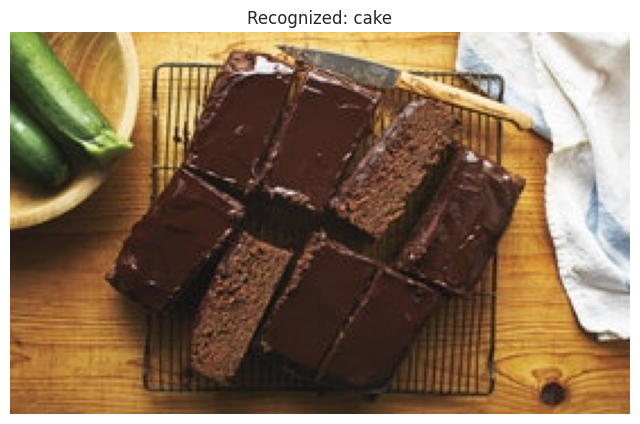


Test 2/3
------------------------------------------------------------
Original: Pepper Chicken with Hummus
Recognized as: grilled chicken

Generated Recipe:
1. RECIPE TITLE: Grilled Lemon Herb Chicken

INGREDIENTS LIST:
- 4 boneless, skinless chicken breasts
- 1 lemon, juiced
- 1 tablespoon olive oil
- 2 tablespoons chopped fresh herbs (such as thyme, rosemary, or parsley)
- Salt and pepper to taste
- Optional toppings: fresh parsley, lemon wedges, or a sprinkle of grated Parmesan cheese

Steps:

1. Preheat the grill to medium-high heat.
2. In a small bowl, whisk together the lemon juice, olive oil, chopped herbs, salt, and pepper.
3. Place the chic...


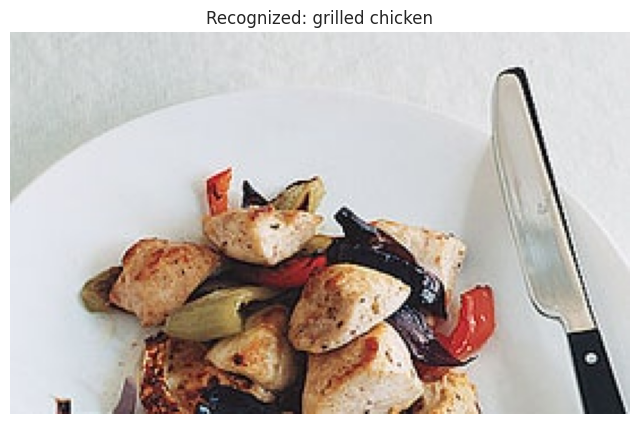


Test 3/3
------------------------------------------------------------
Original: Double Chocolate Espresso Cookies
Recognized as: cookies

Generated Recipe:
Recipe Title: Heavenly Chocolate Chip Cookies
Ingredients:
- 1 cup (2 sticks or 230g) unsalted butter, softened
- 1 cup (200g) granulated sugar
- 1 cup (220g) packed brown sugar
- 2 large eggs
- 1 teaspoon vanilla extract
- 3 cups (375g) all-purpose flour
- 1 teaspoon baking soda
- 1/2 teaspoon salt
- 2 cups (350g) semi-sweet chocolate chips

Instructions:

1. Preheat the oven to 375°F (190°C) and line a baking sheet with parchment paper.

2. In a large mixing bowl, cream together the softened b...


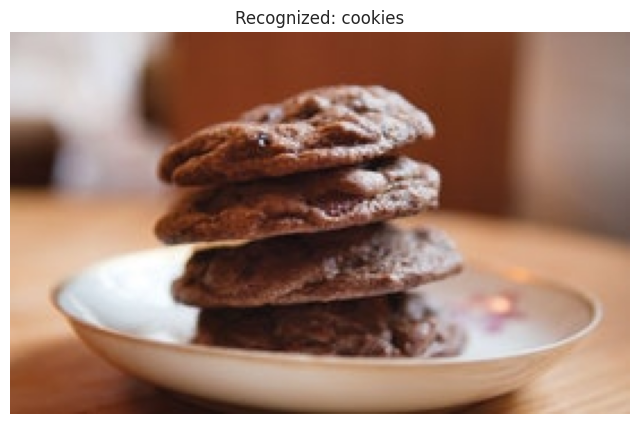


✓ Testing complete!


In [8]:
# Test on a few samples
if processed_data:
    print("\nTesting recipe generation...")
    print("=" * 60)
    
    test_samples = random.sample(processed_data, min(3, len(processed_data)))
    
    for i, sample in enumerate(test_samples, 1):
        print(f"\nTest {i}/{len(test_samples)}")
        print("-" * 60)
        print(f"Original: {sample['title']}")
        
        result = generate_recipe_with_minimax(
            sample['image_path'],
            minimax_model,
            minimax_tokenizer,
            clip_model,
            clip_processor
        )
        
        print(f"Recognized as: {result['recognized_food']}")
        print(f"\nGenerated Recipe:\n{result['recipe'][:500]}...")
        
        # Display image
        if result['image']:
            plt.figure(figsize=(8, 6))
            plt.imshow(result['image'])
            plt.title(f"Recognized: {result['recognized_food']}")
            plt.axis('off')
            plt.show()
    
    print("\n" + "=" * 60)
    print("✓ Testing complete!")


## 7. Create Gradio Web Interface


In [ ]:
import gradio as gr

def gradio_generate_recipe(image):
    """
    Wrapper function for Gradio interface
    """
    if image is None:
        return "⚠️ Please upload an image."
    
    try:
        # Save temp image
        temp_path = "temp_food_image.jpg"
        if isinstance(image, np.ndarray):
            Image.fromarray(image).save(temp_path)
        else:
            image.save(temp_path)
        
        # Generate recipe
        result = generate_recipe_with_minimax(
            temp_path,
            minimax_model,
            minimax_tokenizer,
            clip_model,
            clip_processor,
            max_new_tokens=1024,
            skip_clip=False
        )
        
        # Format output
        output = f"""RECOGNIZED FOOD: {result['recognized_food'].upper()}

{'=' * 60}

{result['recipe']}

{'=' * 60}
NOTE: This recipe was generated by AI and may require refinement.
Please verify ingredients and instructions before cooking.
"""
        
        # Cleanup
        if os.path.exists(temp_path):
            os.remove(temp_path)
        
        return output
        
    except Exception as e:
        return f"❌ Error: {str(e)}"


# Create Gradio interface
with gr.Blocks(title="Food Recipe Generator (Phi-2)", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🍽️ Food to Recipe Generator
    ### Powered by CLIP + Microsoft Phi-2
    
    Upload a food image and get a detailed AI-generated recipe with:
    - 📋 Complete ingredient list
    - ⏱️ Step-by-step instructions
    - 🍳 Cooking guidance
    """)
    
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(
                label="Upload Food Image",
                type="pil",
                height=400
            )
            generate_btn = gr.Button(
                "🚀 Generate Recipe",
                variant="primary",
                size="lg"
            )
            
            gr.Markdown("""
            ### Tips:
            - Upload clear food images
            - Works best with single dishes
            - Powered by Microsoft Phi-2
            """)
        
        with gr.Column(scale=1):
            recipe_output = gr.Textbox(
                label="Generated Recipe",
                lines=25,
                max_lines=30,
                placeholder="Your recipe will appear here...",
                show_copy_button=True
            )
    
    # Connect function
    generate_btn.click(
        fn=gradio_generate_recipe,
        inputs=image_input,
        outputs=recipe_output
    )
    
    image_input.upload(
        fn=gradio_generate_recipe,
        inputs=image_input,
        outputs=recipe_output
    )
    
    gr.Markdown("""
    ---
    **Note**: Recipes are AI-generated and may need refinement.
    
    Built with [CLIP](https://openai.com/research/clip) + [Microsoft Phi-2](https://huggingface.co/microsoft/phi-2) + [Gradio](https://gradio.app)
    """)

print("✓ Gradio interface created!")


✓ Gradio interface created!


## 8. Launch Web Interface


In [10]:
# Launch the interface
try:
    demo.close()
except:
    pass

demo.launch(
    share=True,  # Set to True for public link
    server_name="0.0.0.0",
    server_port=None,
    show_error=True,
    inbrowser=True
)


* Running on local URL:  http://0.0.0.0:7861
* Running on public URL: https://752f123df8692a92df.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Summary

### Key Features:

1. **Model**: Microsoft Phi-2 for recipe generation
2. **Architecture**: Uses CLIP for vision understanding + Phi-2 for text generation
3. **Approach**: CLIP recognizes food type, then Phi-2 generates detailed recipe
4. **Quality**: Efficient and instruction-tuned for better coherence and accuracy

### Advantages:
- ✅ Efficient and lightweight model (2.7B parameters)
- ✅ Better recipe quality with instruction tuning
- ✅ Clearer instructions
- ✅ Integration with CLIP for better understanding
- ✅ Readily available on Hugging Face

### Notes:
- ✅ Model is available and working on Hugging Face
- ✅ Phi-2 is optimized for instruction following
- ✅ Good balance between performance and resource usage

### Next Steps:
1. Fine-tune Phi-2 on food-recipe pairs for better results
2. Add training loop similar to Janus notebook for improved performance
3. Experiment with different prompt formats for better recipe structure

**Overall**: Microsoft Phi-2 provides an efficient and effective approach to recipe generation from food images!
